In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import torchaudio.transforms as T


# ─────────────────────────────────────────────
# PREPROCESSING CONSTANTS
# Confirmed from EDA: 32000 Hz, 5s → (128, 313)
# ─────────────────────────────────────────────
SAMPLE_RATE   = 32000
CLIP_DURATION = 5        # seconds
N_MELS        = 128
HOP_LENGTH    = 512
N_FFT         = 1024
F_MIN         = 50       # ignore very low frequencies (wind noise)
F_MAX         = 14000    # upper bound relevant for bird calls


In [7]:
class BirdCLEFDataset(Dataset):
    """
    PyTorch Dataset for BirdCLEF 2026.

    Handles two data sources:
      1. train_audio/   — clean single-species recordings (single-label)
      2. train_soundscapes/ — real-world multi-species soundscapes (multi-label)

    Each item is a (spectrogram, label_vector) pair where:
      - spectrogram : torch.Tensor of shape (1, N_MELS, T')
      - label_vector: torch.Tensor of shape (K,) — multi-hot binary vector
    """

    def __init__(self, samples, label_encoder, augment=False):
        """
        Args:
            samples      : list of dicts, each with keys:
                             'file_path' : str   — path to .ogg file
                             'offset'    : float — start time in seconds
                             'labels'    : list  — list of species label strings
            label_encoder: fitted MultiLabelBinarizer mapping species → index
            augment      : if True, apply SpecAugment (training set only)
        """
        self.samples       = samples
        self.label_encoder = label_encoder
        self.augment       = augment
        self.n_classes     = len(label_encoder.classes_)

        # SpecAugment: masks random frequency bands and time segments
        # to make the model robust to missing or corrupted regions
        self.freq_mask = T.FrequencyMasking(freq_mask_param=24)
        self.time_mask = T.TimeMasking(time_mask_param=64)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # ── 1. Load the 5-second chunk ───────────────────────────────────────
        y, _ = librosa.load(
            sample['file_path'],
            sr       = SAMPLE_RATE,
            offset   = sample['offset'],
            duration = CLIP_DURATION,
            mono     = True,
        )

        # ── 2. Pad if shorter than 5 seconds ─────────────────────────────────
        # Happens for the last chunk of a recording that doesn't fill 5s fully
        target_len = SAMPLE_RATE * CLIP_DURATION
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)), mode='constant')

        # ── 3. Compute log-mel spectrogram → shape (128, 313) ────────────────
        mel    = librosa.feature.melspectrogram(
            y=y, sr=SAMPLE_RATE, n_fft=N_FFT,
            hop_length=HOP_LENGTH, n_mels=N_MELS, fmin=F_MIN, fmax=F_MAX,
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # ── 4. Normalise to [0, 1] per clip ──────────────────────────────────
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)

        # ── 5. Convert to tensor with channel dim → (1, 128, 313) ────────────
        spec = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)

        # ── 6. Apply SpecAugment (training only) ─────────────────────────────
        if self.augment:
            spec = self.freq_mask(spec)
            spec = self.time_mask(spec)

        # ── 7. Build multi-hot label vector ──────────────────────────────────
        # Works for both single-label (train_audio) and multi-label (soundscapes)
        # since sample['labels'] is always a list, even if it has one element
        known_labels = [l for l in sample['labels'] if l in self.label_encoder.classes_]
        label_vec    = torch.zeros(self.n_classes, dtype=torch.float32)
        if known_labels:
            indices = [np.where(self.label_encoder.classes_ == l)[0][0]
                       for l in known_labels]
            label_vec[indices] = 1.0

        return spec, label_vec


In [8]:
# ─────────────────────────────────────────────
# SAMPLE LIST BUILDERS
# One function per data source, both return
# a list of dicts with the same structure so
# they can be concatenated cleanly.
# ─────────────────────────────────────────────

def build_samples_from_train_audio(df, audio_dir):
    """
    Builds sample list from train_audio/ (clean single-species recordings).

    Each recording is chunked into non-overlapping 5s windows.
    Label is a single-element list to stay consistent with the soundscape format.

    Args:
        df        : pd.DataFrame with columns ['filename', 'primary_label']
        audio_dir : path to train_audio/ folder

    Returns:
        list of dicts with keys: file_path, offset, labels
    """
    samples = []
    for _, row in df.iterrows():
        file_path = os.path.join(audio_dir, row['filename'])
        if not os.path.exists(file_path):
            continue
        duration = row['duration']#librosa.get_duration(path=file_path)
        n_chunks = max(1, int(duration // CLIP_DURATION))
        for chunk_idx in range(n_chunks):
            samples.append({
                'file_path' : file_path,
                'offset'    : chunk_idx * CLIP_DURATION,
                'labels'    : [row['primary_label']],  # single-label, wrapped in list
            })
    return samples


def build_samples_from_soundscapes(labels_csv, soundscapes_dir):
    """
    Builds sample list from labeled train_soundscapes/.

    The labels CSV has columns: filename, start, end, primary_label
    where primary_label is a semicolon-separated list of species codes
    for that 5-second segment (already pre-segmented by expert annotators).

    Args:
        labels_csv      : path to train_soundscapes_labels.csv
        soundscapes_dir : path to train_soundscapes/ folder

    Returns:
        list of dicts with keys: file_path, offset, labels
    """
    df      = pd.read_csv(labels_csv)
    samples = []
    for _, row in df.iterrows():
        file_path = os.path.join(soundscapes_dir, row['filename'])
        if not os.path.exists(file_path):
            continue
        # convert HH:MM:SS start time to seconds
        h, m, s  = str(row['start']).split(':')
        offset_s = int(h) * 3600 + int(m) * 60 + float(s)
        # parse semicolon-separated multi-label species list
        species_list = [s.strip() for s in str(row['primary_label']).split(';')]
        samples.append({
            'file_path' : file_path,
            'offset'    : offset_s,
            'labels'    : species_list,
        })
    return samples


In [9]:
# ─────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────

def build_dataloaders(
    metadata_csv    : str,
    audio_dir       : str,
    soundscapes_dir : str,
    soundscapes_csv : str,
    val_size        : float = 0.15,
    batch_size      : int   = 32,
    num_workers     : int   = 4,
    min_recordings  : int  = 2,
    random_state    : int   = 42,
):
    """
    Builds train and validation DataLoaders from both data sources combined.
 
    The validation set is drawn only from train_audio (clean, single-label)
    to keep evaluation simple and consistent. The soundscape samples are
    added to the training set only, since they represent the real-world
    distribution we want the model to learn from — not to be evaluated on
    using our internal metric.
 
    Args:
        metadata_csv    : path to train_metadata.csv
        audio_dir       : path to train_audio/ folder
        soundscapes_dir : path to train_soundscapes/ folder
        soundscapes_csv : path to train_soundscapes_labels.csv
        val_size        : fraction of train_audio to hold out for validation
        batch_size      : DataLoader batch size
        num_workers     : parallel workers for data loading
        random_state    : random seed for reproducibility
 
    Returns:
        train_loader, val_loader, label_encoder (MultiLabelBinarizer)
    """
 
    # ── 1. Load train_audio metadata ─────────────────────────────────────────
    df = pd.read_csv(metadata_csv)
    print(f"train_audio — recordings: {len(df)}, species: {df['primary_label'].nunique()}")

    # ── 2. Filter species below minimum threshold (fallback scope reduction) ─
    counts = df['primary_label'].value_counts()
    valid_species = counts[counts >= min_recordings].index # we need at least two recordings per class to split 
    df = df[df['primary_label'].isin(valid_species)].reset_index(drop=True)
    print(f"After threshold={min_recordings}: {len(df)} recordings, "
          f"{df['primary_label'].nunique()} species")
 
    # ── 3. Stratified split of train_audio into train / val ──────────────────
    # Val set comes only from train_audio for clean, consistent evaluation
    train_df, val_df = train_test_split(
        df,
        test_size    = val_size,
        stratify     = df['primary_label'],
        random_state = random_state,
    )
    print(f"train_audio split — train: {len(train_df)}, val: {len(val_df)}")
 
    # ── 4. Fit label encoder on ALL species in train_audio ───────────────────
    # We fit on the full df (before split) so val species are always covered.
    # Soundscape species not in train_audio are silently ignored at label
    # building time (see the 'known_labels' filter in __getitem__).
    mlb = MultiLabelBinarizer()
    mlb.fit([[s] for s in sorted(df['primary_label'].unique())])
    print(f"Number of classes K: {len(mlb.classes_)}")
 
    # ── 5. Build sample lists ─────────────────────────────────────────────────
    train_audio_samples     = build_samples_from_train_audio(train_df, audio_dir)
    soundscape_samples      = build_samples_from_soundscapes(soundscapes_csv, soundscapes_dir)
    val_samples             = build_samples_from_train_audio(val_df, audio_dir)
 
    # Training set = clean recordings + real-world soundscapes
    train_samples = train_audio_samples + soundscape_samples
    print(f"Training samples  — audio chunks: {len(train_audio_samples)}, "
          f"soundscape segments: {len(soundscape_samples)}, "
          f"total: {len(train_samples)}")
    print(f"Validation samples: {len(val_samples)}")
 
    # ── 6. Build Dataset objects ──────────────────────────────────────────────
    train_dataset = BirdCLEFDataset(train_samples, mlb, augment=True)
    val_dataset   = BirdCLEFDataset(val_samples,   mlb, augment=False)
 
    # ── 7. Build DataLoaders ──────────────────────────────────────────────────
    train_loader = DataLoader(
        train_dataset,
        batch_size  = batch_size,
        shuffle     = True,
        num_workers = num_workers,
        pin_memory  = True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size  = batch_size,
        shuffle     = False,
        num_workers = num_workers,
        pin_memory  = True,
    )
 
    return train_loader, val_loader, mlb

train_audio — recordings: 35549, species: 206
After threshold=2: 35545 recordings, 202 species
train_audio split — train: 30213, val: 5332
Number of classes K: 202
Training samples  — audio chunks: 91918, soundscape segments: 0, total: 91918
Validation samples: 14954

── Check 1: Training batch ──────────────────────────────────────────


/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidge

Spectrogram shape : torch.Size([8, 1, 128, 313])
Label vector shape: torch.Size([8, 202])
Label sums        : tensor([1., 1., 1., 1., 1., 1., 1., 1.])

── Check 2: Validation batch ────────────────────────────────────────


/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Spectrogram shape : torch.Size([8, 1, 128, 313])
Label vector shape: torch.Size([8, 202])
Label sums        : tensor([1., 1., 1., 1., 1., 1., 1., 1.])

── Check 3: Multi-label soundscape sample ───────────────────────────
No multi-label soundscape sample found — check soundscapes CSV loading.


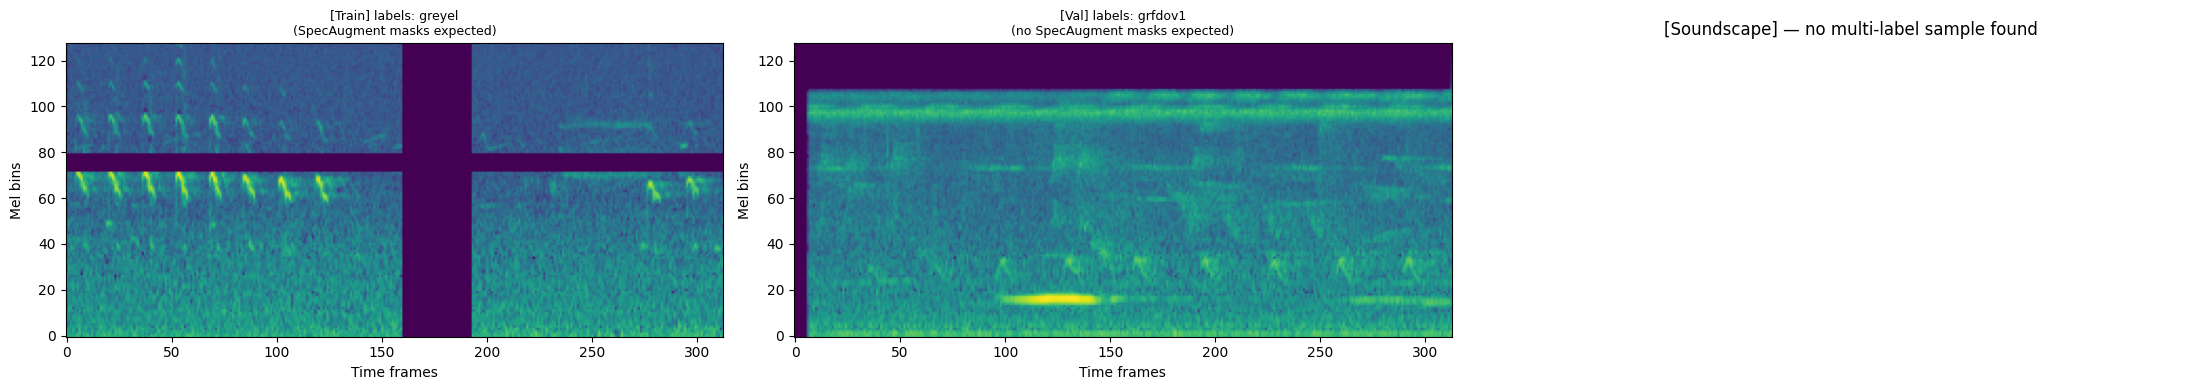

In [10]:
# ─────────────────────────────────────────────
# QUICK SANITY CHECK
# ─────────────────────────────────────────────

if __name__ == "__main__":
    import matplotlib.pyplot as plt

    DATA_DIR        = "/home/renku/work/kaggle-data/birdclef-2026"
    METADATA_CSV    = "/home/renku/work/aml2026-group-10/data/train_with_duration.csv"
    AUDIO_DIR       = f"{DATA_DIR}/train_audio"
    SOUNDSCAPES_DIR = f"{DATA_DIR}/train_soundscapes"
    SOUNDSCAPES_CSV = f"{DATA_DIR}/train_soundscapes_labels.csv"

    train_loader, val_loader, mlb = build_dataloaders(
        metadata_csv    = METADATA_CSV,
        audio_dir       = AUDIO_DIR,
        soundscapes_dir = SOUNDSCAPES_DIR,
        soundscapes_csv = SOUNDSCAPES_CSV,
        val_size        = 0.15,
        batch_size      = 8,
        num_workers     = 2,
    )

    fig, axes = plt.subplots(1, 3, figsize=(22, 4))
 
    # ── Check 1: Training spectrogram (should show SpecAugment masks) ─────────
    print("\n── Check 1: Training batch ──────────────────────────────────────────")
    train_specs, train_labels = next(iter(train_loader))
    print(f"Spectrogram shape : {train_specs.shape}")       # (8, 1, 128, 313)
    print(f"Label vector shape: {train_labels.shape}")      # (8, K)
    print(f"Label sums        : {train_labels.sum(dim=1)}") # all >= 1
 
    ax = axes[0]
    ax.imshow(train_specs[0, 0].numpy(), aspect='auto', origin='lower', cmap='viridis')
    active = mlb.classes_[train_labels[0].bool().numpy()]
    ax.set_title(f"[Train] labels: {', '.join(active)}\n"
                 f"(SpecAugment masks expected)", fontsize=9)
    ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bins")
 
    # ── Check 2: Validation spectrogram (should have NO SpecAugment masks) ────
    print("\n── Check 2: Validation batch ────────────────────────────────────────")
    val_specs, val_labels = next(iter(val_loader))
    print(f"Spectrogram shape : {val_specs.shape}")
    print(f"Label vector shape: {val_labels.shape}")
    print(f"Label sums        : {val_labels.sum(dim=1)}")   # all 1 (single-label)
 
    ax = axes[1]
    ax.imshow(val_specs[0, 0].numpy(), aspect='auto', origin='lower', cmap='viridis')
    active_val = mlb.classes_[val_labels[0].bool().numpy()]
    ax.set_title(f"[Val] labels: {', '.join(active_val)}\n"
                 f"(no SpecAugment masks expected)", fontsize=9)
    ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bins")
 
    # ── Check 3: Multi-label soundscape sample ────────────────────────────────
    print("\n── Check 3: Multi-label soundscape sample ───────────────────────────")
    multi_label_idx = None
    for i, sample in enumerate(train_loader.dataset.samples):
        if len(sample['labels']) > 1:
            multi_label_idx = i
            break
 
    if multi_label_idx is not None:
        spec_ml, label_ml = train_loader.dataset[multi_label_idx]
        sample_ml         = train_loader.dataset.samples[multi_label_idx]
        active_ml         = mlb.classes_[label_ml.bool().numpy()]
        print(f"Found at index    : {multi_label_idx}")
        print(f"Raw labels        : {sample_ml['labels']}")
        print(f"Encoded labels    : {active_ml}")
        print(f"Label vector sum  : {label_ml.sum()}")  # should be > 1
 
        ax = axes[2]
        ax.imshow(spec_ml[0].numpy(), aspect='auto', origin='lower', cmap='viridis')
        ax.set_title(f"[Soundscape] labels: {', '.join(active_ml)}\n"
                     f"label sum = {int(label_ml.sum())} (multi-label expected)", fontsize=9)
        ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bins")
    else:
        print("No multi-label soundscape sample found — check soundscapes CSV loading.")
        axes[2].set_title("[Soundscape] — no multi-label sample found")
        axes[2].axis('off')
 
    plt.tight_layout()
    plt.show()

In [ ]:
# run this ONCE and save to disk
import librosa
import pandas as pd
import os
from tqdm import tqdm

DATA_DIR        = "/home/renku/work/kaggle-data/birdclef-2026"
METADATA_CSV    = "/home/renku/work/aml2026-group-10/data/train_with_duration.csv"
AUDIO_DIR       = f"{DATA_DIR}/train_audio"

df = pd.read_csv(METADATA_CSV)

durations = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    file_path = os.path.join(AUDIO_DIR, row['filename'])
    try:
        d = librosa.get_duration(path=file_path)
    except Exception:
        d = 0.0
    durations.append(d)

df['duration'] = durations
df.to_csv("/home/renku/work/aml2026-group-10/data/train_with_duration.csv", index=False)
print("Done — saved to train_with_duration.csv")